In [1]:
!pip install xgboost lightgbm catboost shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import joblib
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/content/StudentsPerformance_3_lyst1729690388778.csv")

print(df.shape)
df.head()

(1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicates")
print(df.duplicated().sum())

print("\nStatistics")
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

Missing Values
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score         

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [5]:
df["average_score"] = (df["math score"] + df["reading score"] +df["writing score"])/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


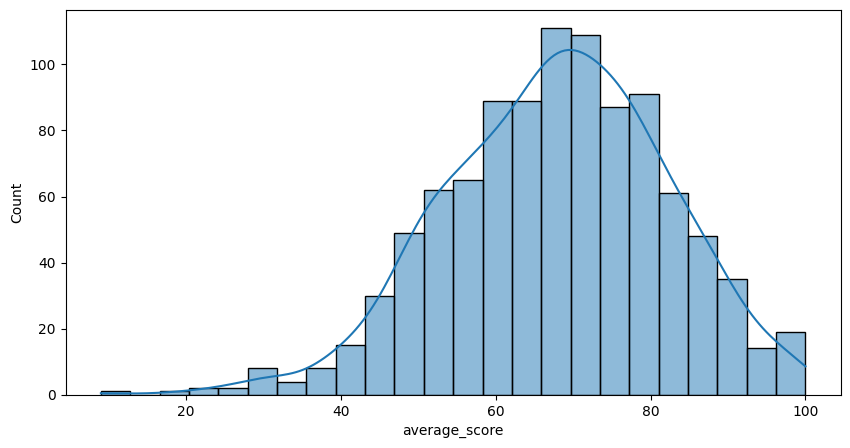

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df["average_score"], kde=True)
plt.show()

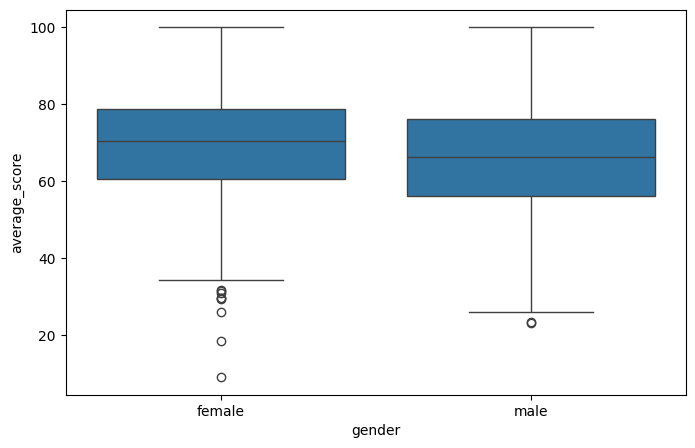

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="gender",
    y="average_score",
    data=df
)
plt.show()

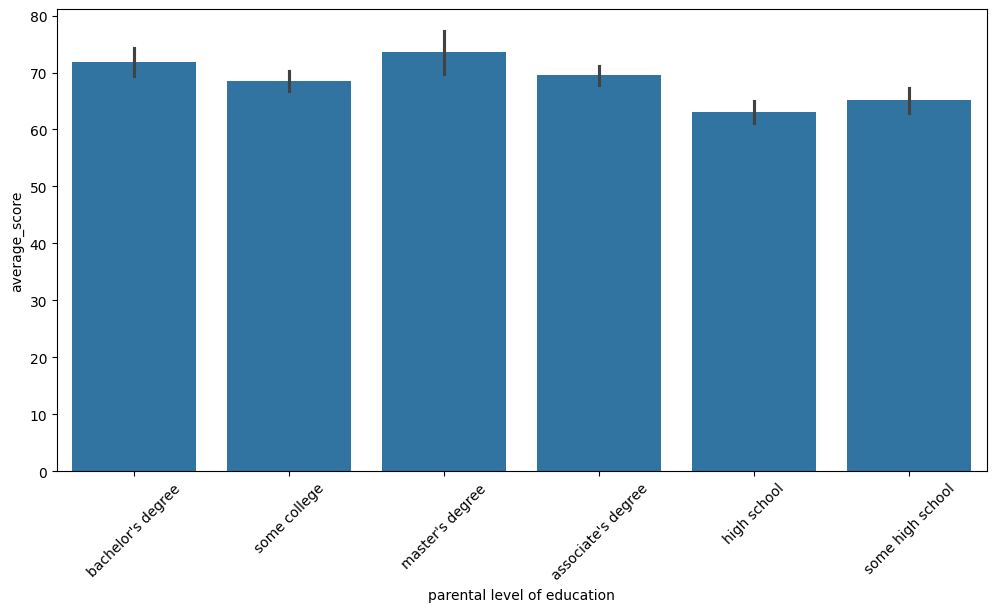

In [8]:
plt.figure(figsize=(12,6))
sns.barplot(
    x="parental level of education",
    y="average_score",
    data=df
)
plt.xticks(rotation=45)
plt.show()

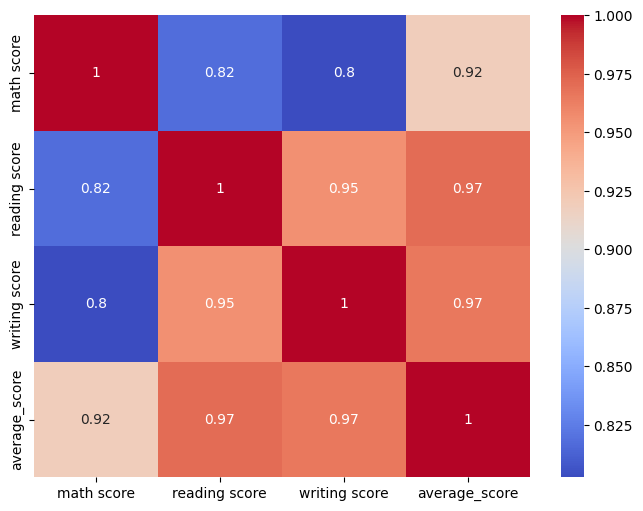

In [9]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [10]:
X = df.drop(
    columns=["math score"]
)

y = df["math score"]

In [11]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns
print(categorical_cols)
print(numerical_cols)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')
Index(['reading score', 'writing score', 'average_score'], dtype='object')


In [12]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")
preprocessor = ColumnTransformer(
    transformers=[("num", numeric_transformer,numerical_cols),("cat", categorical_transformer,categorical_cols)]
)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
models = {
    "Linear Regression":
    LinearRegression(),
    "Decision Tree":
    DecisionTreeRegressor(),
    "Random Forest":
    RandomForestRegressor(),
    "Gradient Boosting":
    GradientBoostingRegressor(),
    "Extra Trees":
    ExtraTreesRegressor(),
    "XGBoost":
    XGBRegressor(),
    "LightGBM":
    LGBMRegressor(),
    "CatBoost":
    CatBoostRegressor(verbose=0)
}

In [15]:
results = []

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)

    r2 = r2_score(y_test, preds)

    results.append([name, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "R2 Score"]
)

results_df.sort_values(
    by="R2 Score",
    ascending=False,
    inplace=True
)

results_df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000306 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 305
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 20
[LightGBM] [Info] Start training from score 66.496250
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,Model,R2 Score
0,Linear Regression,1.000000
5,XGBoost,0.975703
7,CatBoost,0.966141
2,Random Forest,0.963071
4,Extra Trees,0.957137
3,Gradient Boosting,0.955895
6,LightGBM,0.954727
1,Decision Tree,0.934104


In [16]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor())
])

best_model.fit(X_train, y_train)

preds = best_model.predict(X_test)

print(
    "R2 Score:",
    r2_score(y_test, preds)
)

print(
    "MAE:",
    mean_absolute_error(y_test, preds)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, preds))
)

R2 Score: 0.975703239440918
MAE: 1.7755804061889648
RMSE: 2.431529729681392


In [17]:
model = XGBRegressor()

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

pipe.fit(X_train, y_train)

feature_names = (
    numerical_cols.tolist() +
    pipe.named_steps[
        "preprocessor"
    ].transformers_[1][1].get_feature_names_out(
        categorical_cols
    ).tolist()
)

importance = pipe.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
2,average_score,0.542179
3,gender_female,0.353138
16,lunch_free/reduced,0.018776
1,writing score,0.015902
0,reading score,0.015030
9,race/ethnicity_group E,0.014565
18,test preparation course_completed,0.014216
13,parental level of education_master's degree,0.006148
12,parental level of education_high school,0.003086
7,race/ethnicity_group C,0.003056


In [18]:
joblib.dump(
    best_model,
    "student_model.pkl"
)

print("Model Saved")

Model Saved


In [19]:
sample = pd.DataFrame({

    "gender":["female"],
    "race/ethnicity":["group B"],
    "parental level of education":["bachelor's degree"],
    "lunch":["standard"],
    "test preparation course":["completed"],
    "reading score":[90],
    "writing score":[95],
    "average_score":[92]
})

prediction = best_model.predict(sample)

print(
    "Predicted Math Score:",
    prediction[0]
)

Predicted Math Score: 90.14397


In [23]:
!pip install streamlit -q

import streamlit as st
import pandas as pd
import joblib
import plotly.express as px

model = joblib.load(
    "student_model.pkl"
)

df = pd.read_csv(
    "/content/StudentsPerformance_3_lyst1729690388778.csv"
)

st.title(
    "Student Performance Prediction"
)

menu = st.sidebar.selectbox(

    "Menu",

    [

        "Dashboard",

        "Prediction",

        "Analytics"
    ]
)

2026-06-22 06:33:53.177 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 06:33:53.433 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-22 06:33:53.434 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 06:33:53.435 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 06:33:53.436 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 06:33:53.437 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 06:33:53.438 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 06:33:53.438 Thread 'MainThread': mi

In [25]:
df = pd.read_csv("/content/StudentsPerformance_3_lyst1729690388778.csv")

# Train model
best_model.fit(X_train, y_train)

# Save model
import joblib
joblib.dump(best_model, "student_model.pkl")

['student_model.pkl']

In [26]:
from google.colab import files

files.download("student_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
from google.colab import files

files.download("student_model.pkl")
files.download("StudentsPerformance_3_lyst1729690388778.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
!git init
!git config --global user.email "tilaksontana59@gmail.com"
!git config --global user.name "SANATANA TILAK"

!git add .
!git commit -m "Initial Commit"

!git branch -M main

!git remote add origin https://github.com/USERNAME/Student-Performance-Prediction.git

!git push -u origin main

Reinitialized existing Git repository in /content/.git/
On branch main
nothing to commit, working tree clean
error: remote origin already exists.
fatal: could not read Username for 'https://github.com': No such device or address
